# MediPhi LoRA Training (Clean)
This notebook is a cleaned, **run-from-top** training pipeline that:
1. Loads `processed_data_all_entities.csv`
2. Trains a LoRA adapter on your base model
3. **Always saves** (a) Trainer checkpoints **to Drive** and (b) a final PEFT adapter folder containing `adapter_config.json`

After this finishes, you can point all explainability notebooks (SHAP/LIME/etc.) at the saved `ADAPTER_FINAL_DIR`.


## 0. Setup + Drive Mount

In [1]:
# If you're in Colab, mount Drive. If not in Colab, this cell is safe to skip.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except Exception:
    IN_COLAB = False
    print("Not running in Colab (or Drive mount unavailable). Continuing...")


Mounted at /content/drive


## 1. Config

In [2]:

# ====== EDIT THESE ======
DATA_PATH = "/content/drive/MyDrive/processed_data_all_entities.csv"  # must include Radiologist_Report
REPORT_COL = "Radiologist_Report"

# Base model (must be a STRING repo id or local path)
BASE_MODEL = "microsoft/MediPhi"

# Where to write training outputs (checkpoints) and the final adapter
RUNS_DIR = "/content/drive/MyDrive/mediphi-lora-runs"                 # Trainer output_dir (checkpoints)
ADAPTER_FINAL_DIR = "/content/drive/MyDrive/mediphi-lora/adapter_final"  # PEFT adapter export

# Training split choice if your CSV has a split column; otherwise we create a split.
SPLIT_COL = None  # e.g., "split" if you have one. Otherwise leave None.
TRAIN_SPLIT_VALUE = "train"
VAL_SPLIT_VALUE = "val"

# Task labels (optional): set to None if you are doing instruction-style training without labels in the CSV
LABEL_COL = None  # e.g., "Edema_Label"

# Misc
SEED = 42


## 2. Imports

In [3]:
import os, random, math, json
import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    TrainingArguments, Trainer,
    DataCollatorForLanguageModeling,
    set_seed
)

from peft import LoraConfig, get_peft_model


## 3. Load data

In [4]:
set_seed(SEED)

assert isinstance(BASE_MODEL, str), f"BASE_MODEL must be a string, got {type(BASE_MODEL)}"
assert os.path.exists(DATA_PATH), f"DATA_PATH not found: {DATA_PATH}"

df = pd.read_csv(DATA_PATH)
assert REPORT_COL in df.columns, f"Missing column: {REPORT_COL}"
print("Loaded:", df.shape)
df[[REPORT_COL]].head()


Loaded: (3489, 9)


,Radiologist_Report
0,FINDINGS:\nLines and Tubes: None Mediastinum:...
1,"FINDINGS:\nDevices, lines and Tubes: Left arm ..."
2,"FINDINGS:\nLines and Tubes: Impella, AICD, Swa..."
3,FINDINGS:\nSee IMPRESSION.\n\nIMPRESSION: Devi...
4,FINDINGS:\nLines and Tubes: None\nMediastinum:...


## 4. Build training texts
This assumes instruction-style training. If you have labels, it appends the target token(s).

In [5]:
def make_prompt(report: str) -> str:
    # Adjust to match your original training format if needed.
    return (
        "You are a clinical NLP assistant. Determine whether the report indicates pulmonary edema.\n\n"
        f"REPORT:\n{report}\n\n"
        "Answer with exactly one word: present or absent.\n"
        "ANSWER:"
    )

def make_target(label) -> str:
    if label is None:
        return ""
    if isinstance(label, str):
        lab = label.strip().lower()
        if lab in {"present","absent"}:
            return " " + lab
    if isinstance(label, (int, float, np.integer, np.floating)):
        return " present" if int(label) == 1 else " absent"
    return " " + str(label).strip().lower()

def build_text(row) -> str:
    prompt = make_prompt(str(row[REPORT_COL]))
    if LABEL_COL is None:
        return prompt
    return prompt + make_target(row[LABEL_COL])

if LABEL_COL is not None:
    assert LABEL_COL in df.columns, f"Missing LABEL_COL: {LABEL_COL}"

df["text"] = df.apply(build_text, axis=1)
df["text"].head()


,text
0,You are a clinical NLP assistant. Determine wh...
1,You are a clinical NLP assistant. Determine wh...
2,You are a clinical NLP assistant. Determine wh...
3,You are a clinical NLP assistant. Determine wh...
4,You are a clinical NLP assistant. Determine wh...


## 5. Train/Val split

In [6]:
if SPLIT_COL and SPLIT_COL in df.columns:
    train_df = df[df[SPLIT_COL] == TRAIN_SPLIT_VALUE].copy()
    val_df   = df[df[SPLIT_COL] == VAL_SPLIT_VALUE].copy()
    assert len(train_df) > 0 and len(val_df) > 0, "Empty split; check SPLIT_COL values."
else:
    df_shuf = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    cut = int(0.9 * len(df_shuf))
    train_df, val_df = df_shuf.iloc[:cut].copy(), df_shuf.iloc[cut:].copy()

print("Train:", train_df.shape, "Val:", val_df.shape)

train_ds = Dataset.from_pandas(train_df[["text"]])
val_ds   = Dataset.from_pandas(val_df[["text"]])


Train: (3140, 10) Val: (349, 10)


## 6. Tokenizer + tokenize

In [7]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

MAX_LEN = 512  # adjust

def tok(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LEN,
        padding=False,
    )

train_tok = train_ds.map(tok, batched=True, remove_columns=["text"])
val_tok   = val_ds.map(tok, batched=True, remove_columns=["text"])

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

Map:   0%|          | 0/3140 [00:00<?, ? examples/s]

Map:   0%|          | 0/349 [00:00<?, ? examples/s]

## 7. Load base model + attach LoRA

In [8]:
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float16 if torch.cuda.is_available() else None,
    device_map="auto" if torch.cuda.is_available() else None,
)

# LoRA config (edit ranks/targets to match your original)
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    # For Phi-3, common target modules:
    target_modules=["qkv_proj", "o_proj", "gate_up_proj", "down_proj"],
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()


`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

trainable params: 25,165,824 || all params: 3,846,245,376 || trainable%: 0.6543


## 8. TrainingArguments (guaranteed saves)

In [9]:
import inspect
from transformers import TrainingArguments

args_sig = inspect.signature(TrainingArguments.__init__).parameters

common_kwargs = dict(
    output_dir=RUNS_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    logging_steps=10,
    save_strategy="epoch",
    save_total_limit=2,
    fp16=True,
    report_to="none",
)

# ✅ Transformers version compatibility: eval_strategy vs evaluation_strategy
if "eval_strategy" in args_sig:
    training_args = TrainingArguments(
        **common_kwargs,
        eval_strategy="epoch",
    )
elif "evaluation_strategy" in args_sig:
    training_args = TrainingArguments(
        **common_kwargs,
        evaluation_strategy="epoch",
    )
else:
    # No evaluation strategy supported (rare) — train without eval
    training_args = TrainingArguments(**common_kwargs)


## 9. Train

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    data_collator=data_collator,
)

train_out = trainer.train()
train_out


RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

## 10. Save adapter FINAL (what explainability uses)

In [ ]:
os.makedirs(ADAPTER_FINAL_DIR, exist_ok=True)

# Save the PEFT adapter (writes adapter_config.json + adapter weights)
trainer.model.save_pretrained(ADAPTER_FINAL_DIR)
tokenizer.save_pretrained(ADAPTER_FINAL_DIR)

print("Saved adapter to:", ADAPTER_FINAL_DIR)
print("Files:", os.listdir(ADAPTER_FINAL_DIR))
assert os.path.exists(os.path.join(ADAPTER_FINAL_DIR, "adapter_config.json")), "adapter_config.json missing!"


NameError: name 'trainer' is not defined

## 11. Quick smoke test: reload adapter and generate

In [ ]:
from peft import PeftModel

_base = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float16 if torch.cuda.is_available() else None,
    device_map="auto" if torch.cuda.is_available() else None,
)
_loaded = PeftModel.from_pretrained(_base, ADAPTER_FINAL_DIR)
_loaded.eval()

sample = df[REPORT_COL].astype(str).iloc[0][:2000]
prompt = make_prompt(sample)

inputs = tokenizer(prompt, return_tensors="pt").to(_loaded.device)
with torch.no_grad():
    out = _loaded.generate(**inputs, max_new_tokens=3, do_sample=False)
print(tokenizer.decode(out[0], skip_special_tokens=True))


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

ValueError: Can't find 'adapter_config.json' at '/content/drive/MyDrive/mediphi-lora/adapter_final'

## Next steps: Explainability notebooks

After running training above, you should have a **stable adapter folder** at:

- `ADAPTER_FINAL_DIR` (contains `adapter_config.json`)

Use that folder as `LORA_DIR` / `ADAPTER_DIR` in your clean explainability notebooks:

- `clean_inference_shap_mediphi_lora_global.ipynb` (token + global SHAP, negation preserved)
- (optional) LIME / embedding similarity notebooks

**Tip:** If you ever see "Can't find adapter_config.json", it means `ADAPTER_FINAL_DIR` is pointing to the wrong folder or the save step didn't run.


##1. Shap Analysis (Present/Absent cases)

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

BASE_MODEL_ID = "microsoft/MediPhi"
ADAPTER_ID_OR_PATH = "brianthuynh/mediphi-LoRA-Edema"  # OR "/content/drive/MyDrive/.../adapter_final"

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID, use_fast=True)
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
)

model = PeftModel.from_pretrained(base_model, ADAPTER_ID_OR_PATH)
model.eval()

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

adapter_config.json: 0.00B [00:00, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/50.4M [00:00<?, ?B/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Phi3ForCausalLM(
      (model): Phi3Model(
        (embed_tokens): Embedding(32064, 3072, padding_idx=32000)
        (layers): ModuleList(
          (0-31): 32 x Phi3DecoderLayer(
            (self_attn): Phi3Attention(
              (o_proj): lora.Linear(
                (base_layer): Linear(in_features=3072, out_features=3072, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=3072, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=3072, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (qkv_proj

In [ ]:
ADAPTER_ID_OR_PATH = "/content/drive/MyDrive/mediphi-lora/adapter_final"

In [ ]:
import torch
import torch.nn.functional as F

PRESENT_WORD = " present"
ABSENT_WORD  = " absent"

present_ids = tokenizer.encode(PRESENT_WORD, add_special_tokens=False)
absent_ids  = tokenizer.encode(ABSENT_WORD,  add_special_tokens=False)

print("present_ids:", present_ids)
print("absent_ids:", absent_ids)

def build_prompt(report_text: str) -> str:
    return (
        "You are a clinical NLP model. Determine whether pulmonary edema is present.\n"
        "Respond with exactly one word: present or absent.\n\n"
        f"REPORT:\n{report_text}\n\nANSWER:"
    )

@torch.no_grad()
def seq_logprob(prompt: str, cont_ids: list[int]) -> float:
    """
    Computes log P(continuation | prompt) for a specific token-id sequence cont_ids.
    """
    # tokenize prompt without adding specials
    prompt_ids = tokenizer.encode(prompt, add_special_tokens=False)

    # full input = prompt + continuation
    input_ids = torch.tensor([prompt_ids + cont_ids], device=model.device)
    attention_mask = torch.ones_like(input_ids, device=model.device)

    # logits for each position predict next token
    logits = model(input_ids=input_ids, attention_mask=attention_mask).logits  # (1, T, V)
    log_probs = F.log_softmax(logits, dim=-1)

    # continuation tokens start after prompt
    start = len(prompt_ids)

    total = 0.0
    # token at position t is predicted by logits at t-1
    for i, tok_id in enumerate(cont_ids):
        pos = start + i
        total += float(log_probs[0, pos - 1, tok_id].item())

    return total

@torch.no_grad()
def predict_proba_present(report_text: str, max_len: int = 2048) -> float:
    prompt = build_prompt(str(report_text))
    # truncate prompt to leave room for continuation tokens
    # (simple safe truncation by re-tokenizing)
    prompt_ids = tokenizer.encode(prompt, add_special_tokens=False)
    room = max_len - max(len(present_ids), len(absent_ids)) - 1
    if len(prompt_ids) > room:
        prompt_ids = prompt_ids[-room:]
        prompt = tokenizer.decode(prompt_ids)

    lp_present = seq_logprob(prompt, present_ids)
    lp_absent  = seq_logprob(prompt, absent_ids)

    # convert two logprobs into a normalized probability
    # p_present = exp(lp_present) / (exp(lp_present) + exp(lp_absent))
    m = max(lp_present, lp_absent)
    p_present = float(torch.exp(torch.tensor(lp_present - m)) /
                      (torch.exp(torch.tensor(lp_present - m)) + torch.exp(torch.tensor(lp_absent - m))))
    return p_present

present_ids: [29871, 2198]
absent_ids: [29871, 29207]


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

def proba_to_pred_label(p_present: float, thresh: float = 0.5) -> int:
    return int(p_present >= thresh)  # 1=present, 0=absent

#### Split into present vs absent cases

In [ ]:
data = pd.read_csv(DATA_PATH)
data.head(5)

,Accession,Radiologist_Report,Pneumonia_Pneumonitis,Pneumothorax,Cardiomegaly,Pleural_Effusion,Edema,Rib_Fracture,Train/Test/Val
0,53711709,FINDINGS:\nLines and Tubes: None Mediastinum:...,"{'Likelihood': 'none', 'Focality': 'NA', 'Loca...","{'Presence': 'absent', 'Size': 'NA', 'Laterali...","{'Presence': 'unknown', 'Change': 'stable'}","{'Left Presence': 'absent', 'Left Size': 'NA',...","{'Presence': 'absent', 'Severity': 'NA', 'Chan...","{'Presence': 'absent', 'Quantity': 'NA', 'Rib ...",training
1,52575111,"FINDINGS:\nDevices, lines and Tubes: Left arm ...","{'Likelihood': 'none', 'Focality': 'NA', 'Loca...","{'Presence': 'absent', 'Size': 'NA', 'Laterali...","{'Presence': 'present', 'Change': 'stable'}","{'Left Presence': 'present', 'Left Size': 'med...","{'Presence': 'present', 'Severity': 'mild', 'C...","{'Presence': 'unknown', 'Quantity': 'unknown',...",validation
2,53314577,"FINDINGS:\nLines and Tubes: Impella, AICD, Swa...","{'Likelihood': 'none', 'Focality': 'NA', 'Loca...","{'Presence': 'absent', 'Size': 'NA', 'Laterali...","{'Presence': 'present', 'Change': 'stable'}","{'Left Presence': 'present', 'Left Size': 'unk...","{'Presence': 'present', 'Severity': 'moderate'...","{'Presence': 'unknown', 'Quantity': 'unknown',...",testing
3,54209096,FINDINGS:\nSee IMPRESSION.\n\nIMPRESSION: Devi...,"{'Likelihood': 'high', 'Focality': 'multifocal...","{'Presence': 'absent', 'Size': 'NA', 'Laterali...","{'Presence': 'unknown', 'Change': 'stable'}","{'Left Presence': 'present', 'Left Size': 'sma...","{'Presence': 'unknown', 'Severity': 'unknown',...","{'Presence': 'unknown', 'Quantity': 'unknown',...",testing
4,52528408,FINDINGS:\nLines and Tubes: None\nMediastinum:...,"{'Likelihood': 'none', 'Focality': 'NA', 'Loca...","{'Presence': 'absent', 'Size': 'NA', 'Laterali...","{'Presence': 'absent', 'Change': 'stable'}","{'Left Presence': 'absent', 'Left Size': 'NA',...","{'Presence': 'absent', 'Severity': 'NA', 'Chan...","{'Presence': 'unknown', 'Quantity': 'unknown',...",testing


In [ ]:
import re

present_kw = [
    r"\bpulmonary edema\b", r"\binterstitial edema\b", r"\bvascular congestion\b",
    r"\bperihilar\b", r"\bCHF\b", r"\bfluid overload\b"
]
absent_kw = [
    r"\bno (pulmonary )?edema\b", r"\bwithout edema\b", r"\bnegative for edema\b"
]

def has_any(text, patterns):
    t = str(text)
    return any(re.search(p, t, flags=re.IGNORECASE) for p in patterns)

present_df = df[df[REPORT_COL].apply(lambda t: has_any(t, present_kw) and not has_any(t, absent_kw))].copy()
absent_df  = df[df[REPORT_COL].apply(lambda t: has_any(t, absent_kw))].copy()

In [ ]:
import shap

def shap_predict(texts):
    # texts: list[str] → return shape (n, ) or (n,1)
    return np.array([predict_proba_present(t) for t in texts])

explainer = shap.Explainer(shap_predict, shap.maskers.Text(tokenizer))

In [ ]:
import string

NEGATION_KEEP = {
    "no","not","without","negative","denies","denied","absence","absent","rule","out","never","none"
}

STOPWORDS = {
    # small, safe list (you can expand)
    "a","an","the","and","or","but","if","then","so","to","of","in","on","for","with","as","at",
    "is","are","was","were","be","been","being","by","from","this","that","these","those",
    "there","here","it","its","he","she","they","them","we","you","i","patient","patients"
}

def normalize_token(tok: str) -> str:
    # common tokenizer artifacts
    t = tok.replace("▁","").replace("Ġ","").replace("##","")
    return t.strip()

def is_filler(tok_norm: str) -> bool:
    if tok_norm == "":
        return True
    # punctuation-only
    if all(ch in string.punctuation for ch in tok_norm):
        return True
    low = tok_norm.lower()
    if low in NEGATION_KEEP:
        return False
    if low in STOPWORDS:
        return True
    return False

In [ ]:
def top_tokens_from_shap(shap_values, top_k=20, target="present"):
    # shap_values is returned by explainer([text]) → Explanation
    # for our scalar output: shap_values.values shape is (tokens,)
    tokens = shap_values.data[0]              # list of tokens
    vals   = shap_values.values[0]            # np array aligned to tokens

    rows = []
    for tok, v in zip(tokens, vals):
        tn = normalize_token(tok)
        if is_filler(tn):
            continue
        rows.append((tn, float(v)))

    # For P(present): positive SHAP pushes toward present; negative pushes toward absent
    if target == "present":
        rows = sorted(rows, key=lambda x: x[1], reverse=True)[:top_k]
    elif target == "absent":
        rows = sorted(rows, key=lambda x: x[1])[:top_k]  # most negative
    return rows

In [ ]:
N_CASES = 25   # start small; SHAP is expensive
present_sample = present_df.sample(min(N_CASES, len(present_df)), random_state=0)
absent_sample  = absent_df.sample(min(N_CASES, len(absent_df)), random_state=0)

##Compute SHAP + aggregate token contributions per group, creates global tokens for each group

from collections import defaultdict
import numpy as np

def aggregate_group(df_subset, group_name, max_len=1800):
    tok_sum = defaultdict(float)
    tok_cnt = defaultdict(int)

    for i, text in enumerate(df_subset[REPORT_COL].tolist()):
        text = str(text)[:max_len]
        sv = explainer([text])  # Explanation
        tokens = sv.data[0]
        vals   = sv.values[0]

        for tok, v in zip(tokens, vals):
            tn = normalize_token(tok)
            if is_filler(tn):
                continue
            tok_sum[tn] += float(v)
            tok_cnt[tn] += 1

        if (i+1) % 5 == 0:
            print(f"{group_name}: explained {i+1}/{len(df_subset)}")

    # mean SHAP per token occurrence (signed)
    tok_mean = {t: tok_sum[t] / tok_cnt[t] for t in tok_sum.keys()}
    return tok_mean

present_tok_mean = aggregate_group(present_sample, "PRESENT_GROUP")
absent_tok_mean  = aggregate_group(absent_sample,  "ABSENT_GROUP")

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [01:14, 74.19s/it]               


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [01:10, 70.35s/it]               


  0%|          | 0/498 [00:00<?, ?it/s]

...

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [01:11, 71.28s/it]               


ABSENT_GROUP: explained 15/16


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [01:12, 72.75s/it]               


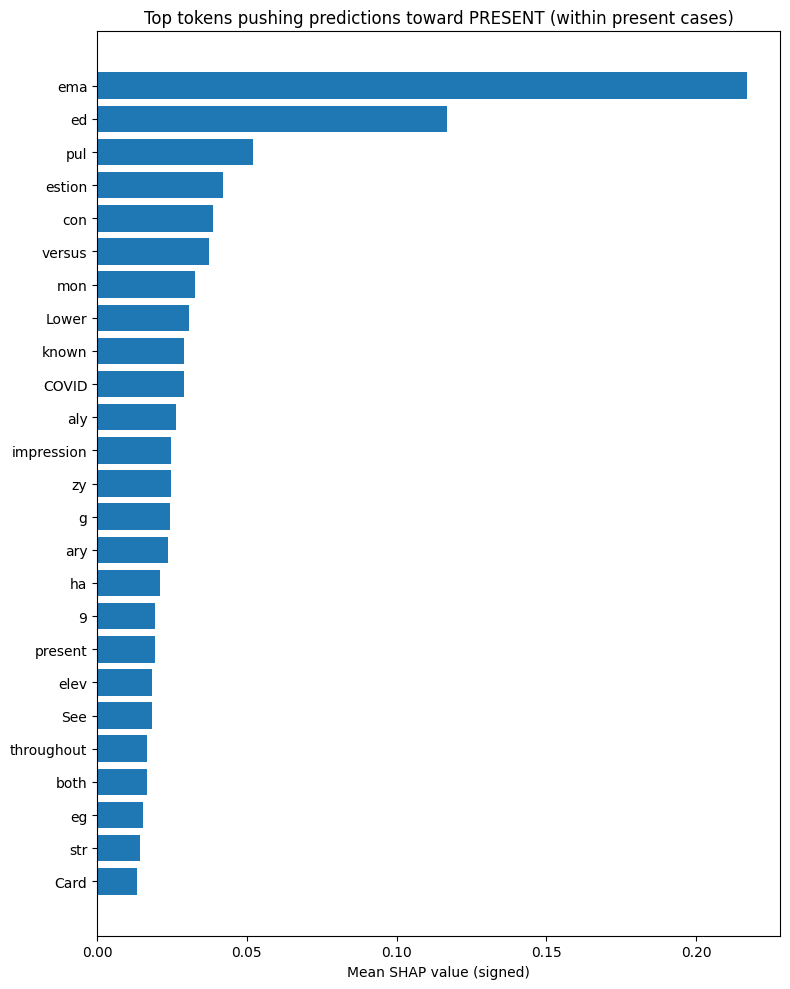

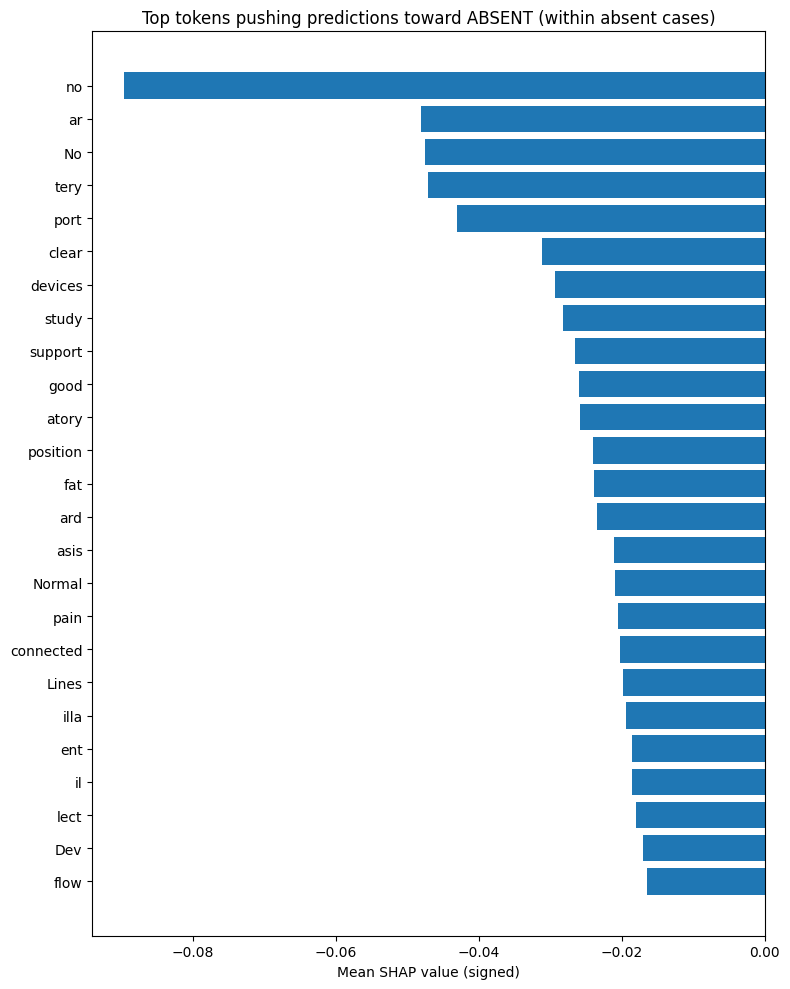

In [ ]:
import pandas as pd

def top_signed(tok_mean, top_k=25, direction="positive"):
    items = list(tok_mean.items())
    if direction == "positive":
        items = [x for x in items if x[1] > 0]
        items = sorted(items, key=lambda x: x[1], reverse=True)[:top_k]
    else:
        items = [x for x in items if x[1] < 0]
        items = sorted(items, key=lambda x: x[1])[:top_k]  # most negative first
    return pd.DataFrame(items, columns=["token", "mean_shap"])

top_present_tokens = top_signed(present_tok_mean, top_k=25, direction="positive")
top_absent_tokens  = top_signed(absent_tok_mean,  top_k=25, direction="negative")

top_present_tokens.head(), top_absent_tokens.head()


import matplotlib.pyplot as plt

def plot_bar(df_tokens, title):
    plt.figure(figsize=(8, 10))
    plt.barh(df_tokens["token"][::-1], df_tokens["mean_shap"][::-1])
    plt.title(title)
    plt.xlabel("Mean SHAP value (signed)")
    plt.tight_layout()
    plt.show()

plot_bar(top_present_tokens, "Top tokens pushing predictions toward PRESENT (within present cases)")
plot_bar(top_absent_tokens,  "Top tokens pushing predictions toward ABSENT (within absent cases)")

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

sns.set_theme(style="whitegrid", font_scale=1.05)

def plot_bar_seaborn(df_tokens, title, annotate=True):
    """
    df_tokens: DataFrame with columns ['token','mean_shap'].
    Produces a poster-friendly horizontal bar chart with coolwarm shading.
    """
    dfp = df_tokens.copy()
    # order so the biggest magnitude appears at top visually
    dfp = dfp.sort_values("mean_shap", ascending=True)

    # map SHAP values to colors using coolwarm centered at 0
    vmin = dfp["mean_shap"].min()
    vmax = dfp["mean_shap"].max()
    norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
    cmap = mpl.cm.get_cmap("coolwarm")
    colors = [cmap(norm(v)) for v in dfp["mean_shap"].values]

    plt.figure(figsize=(9, 10))
    ax = sns.barplot(
        data=dfp,
        y="token",
        x="mean_shap",
        palette=colors,
        dodge=False
    )

    ax.axvline(0, linewidth=1)
    ax.set_title(title, pad=12, weight="bold")
    ax.set_xlabel("Mean SHAP value (signed)")
    ax.set_ylabel("")
    sns.despine(left=True, bottom=False)

    # optional annotations at the end of bars
    if annotate:
        for p, v in zip(ax.patches, dfp["mean_shap"].values):
            x = p.get_width()
            y = p.get_y() + p.get_height()/2
            # place text slightly outside the bar end
            offset = 0.01 * (vmax - vmin + 1e-9)
            ax.text(
                x + (offset if v >= 0 else -offset),
                y,
                f"{v:.2f}",
                va="center",
                ha="left" if v >= 0 else "right",
                fontsize=9
            )

    # add a colorbar legend for the coolwarm mapping
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label("SHAP value", rotation=90)

    plt.tight_layout()
    plt.show()

# Use your same dfs:
plot_bar_seaborn(
    top_present_tokens,
    "Top tokens pushing predictions toward PRESENT (within present cases)",
    annotate=True
)

plot_bar_seaborn(
    top_absent_tokens,
    "Top tokens pushing predictions toward ABSENT (within absent cases)",
    annotate=True
)

## 2. LIME (perturbations on present/absent cases)

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

BASE_MODEL_ID = "microsoft/MediPhi"
ADAPTER_ID_OR_PATH = "brianthuynh/mediphi-LoRA-Edema"  # OR "/content/drive/MyDrive/.../adapter_final"

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID, use_fast=True)
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
)

model = PeftModel.from_pretrained(base_model, ADAPTER_ID_OR_PATH)
model.eval()

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Phi3ForCausalLM(
      (model): Phi3Model(
        (embed_tokens): Embedding(32064, 3072, padding_idx=32000)
        (layers): ModuleList(
          (0-31): 32 x Phi3DecoderLayer(
            (self_attn): Phi3Attention(
              (o_proj): lora.Linear(
                (base_layer): Linear(in_features=3072, out_features=3072, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=3072, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=3072, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (qkv_proj

rerrun all shap cells before method shap_prediction()

In [ ]:
!pip -q install lime

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lime.lime_text import LimeTextExplainer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 21.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
CLASS_NAMES = ["absent", "present"]

def lime_classifier_fn(texts):
    # texts: list[str]
    p_present = np.array([predict_proba_present(t) for t in texts], dtype=float)
    p_absent = 1.0 - p_present
    return np.vstack([p_absent, p_present]).T  # (n, 2)

In [ ]:
explainer = LimeTextExplainer(
    class_names=CLASS_NAMES,
    split_expression=r"\W+",   # split on non-letters/numbers
    bow=True
)

In [ ]:
def run_lime_and_plot(text, title="", num_features=15, num_samples=2000):
    exp = explainer.explain_instance(
        text_instance=text,
        classifier_fn=lime_classifier_fn,
        labels=[1, 0],          # explain both present and absent
        num_features=num_features,
        num_samples=num_samples
    )

    # weights for "present" class (index 1)
    weights_present = exp.as_list(label=1)  # list of (token, weight)

    dfw = pd.DataFrame(weights_present, columns=["token", "weight"]).sort_values("weight")
    plt.figure(figsize=(8, 6))
    plt.barh(dfw["token"], dfw["weight"])
    plt.title(title or "LIME token weights for class: present")
    plt.xlabel("LIME weight (positive pushes toward present)")
    plt.tight_layout()
    plt.show()

    return exp, dfw

In [ ]:
def remove_token_word(text, word):
    # remove whole-word occurrences (case-insensitive)
    pattern = rf"\b{re.escape(word)}\b"
    return re.sub(pattern, "", text, flags=re.IGNORECASE)

def perturbation_delta(text, word):
    p0 = predict_proba_present(text)
    t_removed = remove_token_word(text, word)
    p1 = predict_proba_present(t_removed)
    return {
        "word": word,
        "p_present_original": p0,
        "p_present_removed": p1,
        "delta_removed_minus_original": p1 - p0
    }


[PRESENT example 1] P(present)=0.453


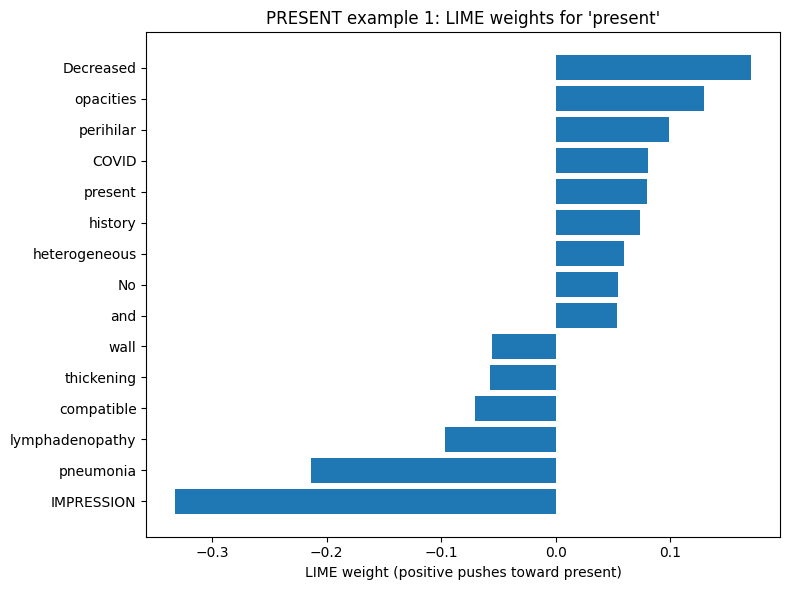


[PRESENT example 2] P(present)=0.983


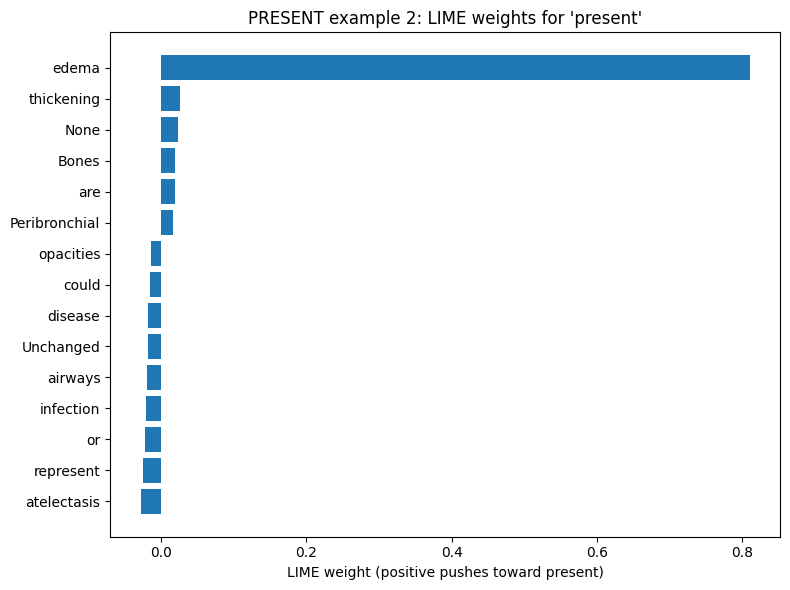


[PRESENT example 3] P(present)=0.988


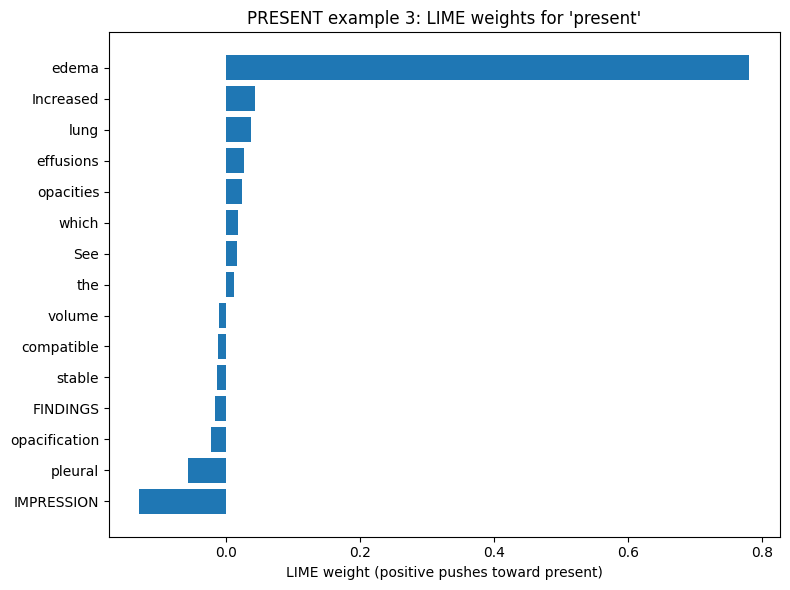

,word,p_present_original,p_present_removed,delta_removed_minus_original,example
0,edema,0.453262,0.453262,0.000000,present_1
1,congestion,0.453262,0.453262,0.000000,present_1
2,edema,0.982553,0.032078,-0.950475,present_2
3,congestion,0.982553,0.982553,0.000000,present_2
4,edema,0.988318,0.040807,-0.947511,present_3
5,congestion,0.988318,0.988318,0.000000,present_3


In [ ]:
##chosen tokens Run this for PRESENT cases (focus tokens: edema, congestion)
N_EX = 3
present_examples = present_df.sample(min(N_EX, len(present_df)), random_state=0)[REPORT_COL].astype(str).tolist()

present_focus_words = ["edema", "congestion"]

all_present_rows = []

for i, txt in enumerate(present_examples, 1):
    txt_short = txt[:1800]  # keep reasonable length
    p = predict_proba_present(txt_short)
    print(f"\n[PRESENT example {i}] P(present)={p:.3f}")

    # LIME plot
    exp, dfw = run_lime_and_plot(
        txt_short,
        title=f"PRESENT example {i}: LIME weights for 'present'",
        num_features=15,
        num_samples=2000
    )

    # Target perturbations
    for w in present_focus_words:
        row = perturbation_delta(txt_short, w)
        row["example"] = f"present_{i}"
        all_present_rows.append(row)

pd.DataFrame(all_present_rows)


[ABSENT example 1] P(present)=0.101


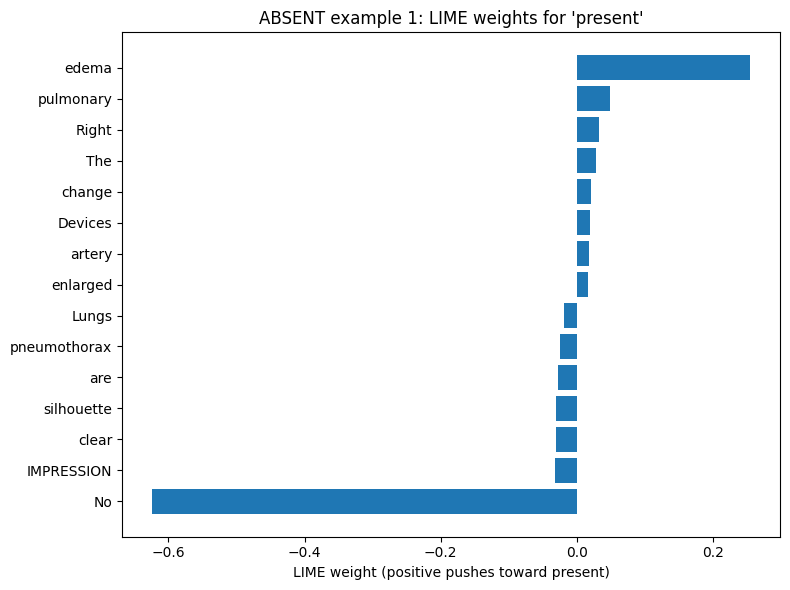


[ABSENT example 2] P(present)=0.033


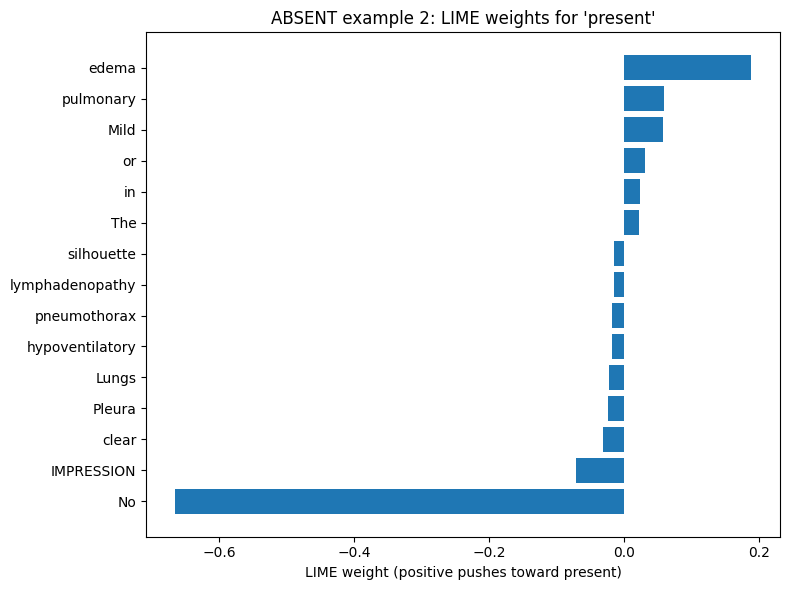


[ABSENT example 3] P(present)=0.041


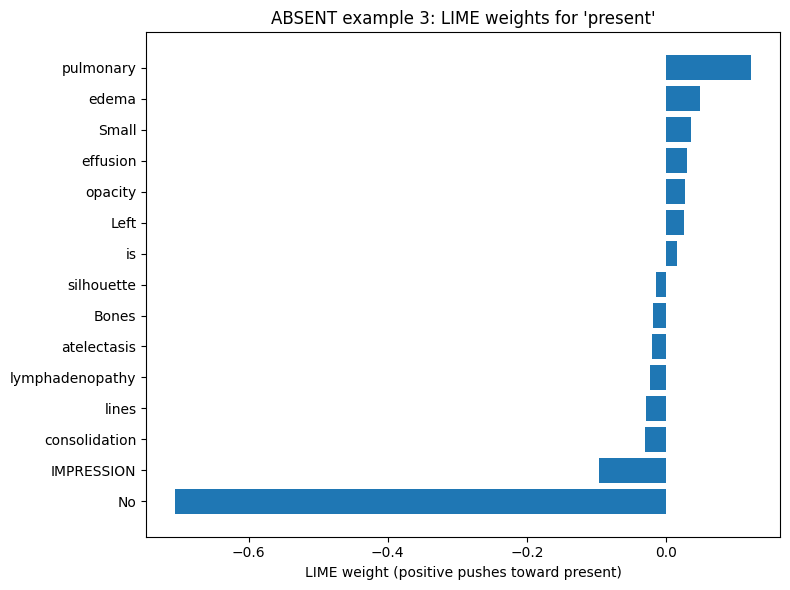

,word,p_present_original,p_present_removed,delta_removed_minus_original,example
0,no,0.100702,0.999912,0.899211,absent_1
1,clear,0.100702,0.151781,0.051079,absent_1
2,no,0.033117,0.999791,0.966673,absent_2
3,clear,0.033117,0.044681,0.011564,absent_2
4,no,0.040884,0.999961,0.959077,absent_3
5,clear,0.040884,0.040884,0.000000,absent_3


In [ ]:
##chosen tokens Run this for ABSENT cases (focus tokens: no, clear)

N_EX = 3
absent_examples = absent_df.sample(min(N_EX, len(absent_df)), random_state=1)[REPORT_COL].astype(str).tolist()



absent_focus_words = ["no", "clear"]

all_absent_rows = []

for i, txt in enumerate(absent_examples, 1):
    txt_short = txt[:1800]
    p = predict_proba_present(txt_short)
    print(f"\n[ABSENT example {i}] P(present)={p:.3f}")

    exp, dfw = run_lime_and_plot(
        txt_short,
        title=f"ABSENT example {i}: LIME weights for 'present'",
        num_features=15,
        num_samples=2000
    )

    for w in absent_focus_words:
        row = perturbation_delta(txt_short, w)
        row["example"] = f"absent_{i}"
        all_absent_rows.append(row)

pd.DataFrame(all_absent_rows)

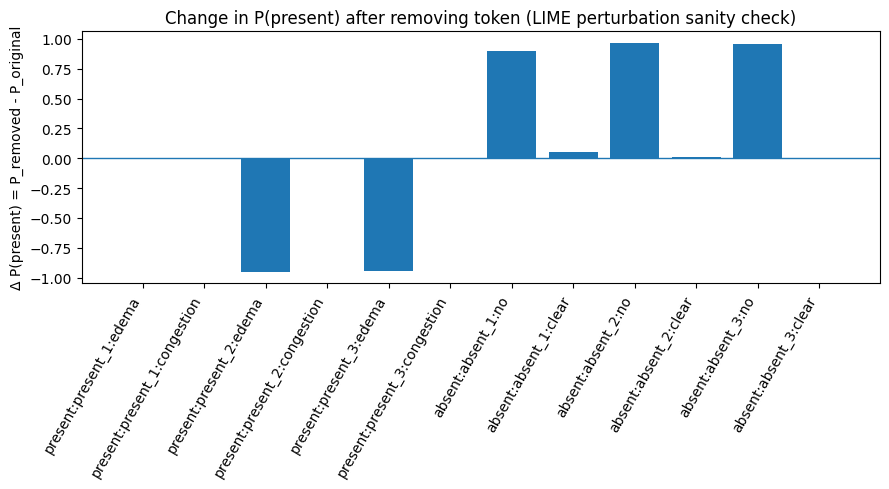

,word,p_present_original,p_present_removed,delta_removed_minus_original,example,group
2,edema,0.982553,0.032078,-0.950475,present_2,present
4,edema,0.988318,0.040807,-0.947511,present_3,present
1,congestion,0.453262,0.453262,0.000000,present_1,present
0,edema,0.453262,0.453262,0.000000,present_1,present
3,congestion,0.982553,0.982553,0.000000,present_2,present
5,congestion,0.988318,0.988318,0.000000,present_3,present
11,clear,0.040884,0.040884,0.000000,absent_3,absent
9,clear,0.033117,0.044681,0.011564,absent_2,absent
7,clear,0.100702,0.151781,0.051079,absent_1,absent
6,no,0.100702,0.999912,0.899211,absent_1,absent


In [ ]:
df_delta = pd.concat([
    pd.DataFrame(all_present_rows).assign(group="present"),
    pd.DataFrame(all_absent_rows).assign(group="absent")
], ignore_index=True)

# Plot delta per example
plt.figure(figsize=(9, 5))
labels = [f"{r.group}:{r.example}:{r.word}" for r in df_delta.itertuples()]
plt.bar(labels, df_delta["delta_removed_minus_original"])
plt.xticks(rotation=60, ha="right")
plt.axhline(0, linewidth=1)
plt.title("Change in P(present) after removing token (LIME perturbation sanity check)")
plt.ylabel("Δ P(present) = P_removed - P_original")
plt.tight_layout()
plt.show()

df_delta.sort_values("delta_removed_minus_original")

## NEW LIME APPROACH: averaging probabilites across entire test set
#### 4 classes: absent, mild, moderate, severe

In [ ]:
# -------------------------
# 2) Parse GT Presence/Severity from Edema text
# -------------------------
import json
import ast
import re
import pandas as pd

def parse_edema_any(s):
    """
    Handles:
    - Multiline: 'Presence: absent\\nSeverity: NA\\nChange: NA'
    - JSON-like: '{"Presence":"absent","Severity":"NA","Change":"NA"}'
    - Python dict-like: "{'Presence': 'absent', 'Severity': 'NA', 'Change': 'NA'}"
    """
    if pd.isna(s):
        return {"Presence": None, "Severity": None}

    text = str(s).strip()

    # 1) Try JSON
    if text.startswith("{") and text.endswith("}"):
        # Try JSON first
        try:
            obj = json.loads(text)
            return {
                "Presence": str(obj.get("Presence", "")).strip().lower() or None,
                "Severity": str(obj.get("Severity", "")).strip().lower() or None,
            }
        except Exception:
            pass
        # Try python dict literal
        try:
            obj = ast.literal_eval(text)
            if isinstance(obj, dict):
                return {
                    "Presence": str(obj.get("Presence", "")).strip().lower() or None,
                    "Severity": str(obj.get("Severity", "")).strip().lower() or None,
                }
        except Exception:
            pass

    # 2) Multiline / free text fallback (flexible)
    # Allow "Presence:" or "Presence =" etc.
    def grab(key):
        m = re.search(rf"{key}\s*[:=]\s*([^\n\r,}}]+)", text, flags=re.IGNORECASE)
        if not m:
            return None
        val = m.group(1).strip().lower()
        val = re.sub(r"[\"'\s]+$", "", val).strip()
        val = re.sub(r"^[\"'\s]+", "", val).strip()
        return val or None

    return {"Presence": grab("Presence"), "Severity": grab("Severity")}

In [ ]:
# Column names in your CSV
REPORT_COL = "Radiologist_Report"
EDEMA_COL  = "Edema"



parsed = df[EDEMA_COL].apply(parse_edema_any).apply(pd.Series)
df["gt_Presence"] = parsed["Presence"]
df["gt_Severity"] = parsed["Severity"]

print("GT Presence counts:\n", df["gt_Presence"].value_counts(dropna=False).head(15))
print("\nGT Severity counts:\n", df["gt_Severity"].value_counts(dropna=False).head(15))

GT Presence counts:
 gt_Presence
absent     2334
present     681
unknown     473
none          1
Name: count, dtype: int64

GT Severity counts:
 gt_Severity
na          2335
unknown      539
mild         359
moderate     182
trace         55
severe        19
Name: count, dtype: int64


In [ ]:
def make_bucket4(row, map_trace_to_mild=True):
    p = (row["gt_Presence"] or "").strip().lower()
    s = (row["gt_Severity"] or "").strip().lower()

    # absent bucket
    if "absent" in p:
        return "absent"

    # present buckets
    if "present" in p:
        if "severe" in s:
            return "severe"
        if "moderate" in s:
            return "moderate"
        if "mild" in s:
            return "mild"
        if map_trace_to_mild and "trace" in s:
            return "mild"
        return None

    return None

df["bucket4"] = df.apply(make_bucket4, axis=1)
print("Bucket4 counts:\n", df["bucket4"].value_counts(dropna=False))

test_df = df.dropna(subset=["bucket4"]).copy()
print("Usable rows for 4-bucket LIME:", len(test_df))

Bucket4 counts:
 bucket4
absent      2334
None         540
mild         414
moderate     182
severe        19
Name: count, dtype: int64
Usable rows for 4-bucket LIME: 2949


In [ ]:
# PROMPT_TEMPLATE = """You are a radiologist’s assistant bot. Extract and report structured information related to [pulmonary edema] from the following chest X-ray report.

# Respond strictly in the following format. Use only the options listed below. Do not add extra words, explanations, or categories.

# Return your final output as a dictionary with the following keys:
# "Presence", "Severity", and "Change"
# Each key should map to a string.

# Example output format:
# {{
# "Presence": "present",
# "Severity": "moderate",
# "Change": "increased"
# }}

# Valid options:

# Presence:
# present
# absent
# unknown

# Severity:
# NA
# trace
# mild
# moderate
# severe
# unknown

# Change:
# stable
# increased
# decreased
# unknown
# NA

# Guidelines:

# - If pulmonary edema is explicitly ruled out or the lungs are described as clear, set "Presence" to "absent" and set both "Severity" and "Change" to "NA".
# - Findings such as peribronchial cuffing, Kerley B lines, perihilar opacities, or reticular opacities may suggest edema but are not definitive. Use clinical judgment to decide whether these findings represent pulmonary edema versus other processes such as atelectasis or pneumonia.
# - If edema is mentioned but its presence is uncertain or descriptions are ambiguous, set "Presence" to "unknown".
# - If "Presence" is "present", assign "Severity" based on the report. If a severity range is given, choose the greater severity. If severity is not specified or is ambiguous, use "unknown".
# - Assign "Change" only when edema is present. If edema is absent, set "Change" to "NA". If change over time is not described or is ambiguous, set "Change" to "unknown".
# - Do not infer change without explicit comparative language.

# ### Now read the following radiology report and extract the required fields:
# {report_text}
# """

# def build_prompt_structured(report_text: str) -> str:
#     return PROMPT_TEMPLATE.format(report_text=report_text)


PROMPT_LIME = """Extract pulmonary edema labels from this CXR report.

Return a dictionary with:
Presence: present/absent
Severity: mild/moderate/severe/NA

Report:
{report_text}
"""

def build_prompt_structured(report_text: str) -> str:
    return PROMPT_LIME.format(report_text=report_text)

In [ ]:
# -------------------------
# 6) Logprob scoring for multi-token continuations
# -------------------------
@torch.no_grad()
def seq_logprob(prompt: str, cont_ids: list[int]) -> float:
    prompt_ids = tokenizer.encode(prompt, add_special_tokens=False)
    input_ids = torch.tensor([prompt_ids + cont_ids], device=model.device)
    attn = torch.ones_like(input_ids, device=model.device)

    logits = model(input_ids=input_ids, attention_mask=attn).logits
    log_probs = F.log_softmax(logits, dim=-1)

    start = len(prompt_ids)
    total = 0.0
    for i, tok_id in enumerate(cont_ids):
        pos = start + i
        total += float(log_probs[0, pos - 1, tok_id].item())
    return total


In [ ]:
# -------------------------
# 7) 4-bucket probability function (scores canonical Presence+Severity prefix)

# -------------------------

CLASSES4 = ["absent", "mild", "moderate", "severe"]
CANON = {
    "absent":   '{\n"Presence": "absent",\n"Severity": "NA",\n',
    "mild":     '{\n"Presence": "present",\n"Severity": "mild",\n',
    "moderate": '{\n"Presence": "present",\n"Severity": "moderate",\n',
    "severe":   '{\n"Presence": "present",\n"Severity": "severe",\n',
}
CANON_IDS = {k: tokenizer.encode(v, add_special_tokens=False) for k, v in CANON.items()}

@torch.no_grad()
def predict_proba_4bucket(report_text: str, max_len: int = 2048):
    prompt = build_prompt_structured(str(report_text))

    prompt_ids = tokenizer.encode(prompt, add_special_tokens=False)
    room = max_len - max(len(v) for v in CANON_IDS.values()) - 1
    if len(prompt_ids) > room:
        prompt_ids = prompt_ids[-room:]
        prompt = tokenizer.decode(prompt_ids)

    lps = np.array([seq_logprob(prompt, CANON_IDS[c]) for c in CLASSES4], dtype=np.float64)
    lps -= lps.max()
    probs = np.exp(lps) / np.exp(lps).sum()
    return probs

# quick sanity check on one row (safe)
ex = test_df.iloc[0][REPORT_COL]
print("\nSanity probs:", dict(zip(CLASSES4, predict_proba_4bucket(str(ex)[:1000]))))



Sanity probs: {'absent': np.float64(0.9972108187287584), 'mild': np.float64(0.0025215399204248177), 'moderate': np.float64(0.0002011159900098207), 'severe': np.float64(6.652536080719345e-05)}


In [ ]:
# -------------------------
# 8) LIME explainer + classifier_fn (returns (n,4))
# -------------------------
# lime_explainer_4 = LimeTextExplainer(
#     class_names=CLASSES4,
#     split_expression=r"[A-Za-z]+(?:'[A-Za-z]+)?",  # words only (more stable than \W+)
#     bow=True
# )

!pip -q install lime

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lime.lime_text import LimeTextExplainer

lime_explainer_4 = LimeTextExplainer(
    class_names=CLASSES4,
    split_expression=r"\W+",
    bow=True
)

def lime_classifier_fn_4(texts):
    return np.vstack([predict_proba_4bucket(t) for t in texts])

In [ ]:
# -------------------------
# 9) Token cleaning (light filter; keep negations)
# -------------------------

def clean_tok(t):
    t = str(t).lower().strip()
    t = re.sub(r"^\W+|\W+$", "", t)
    return t

import re

NEG_KEEP = {"no","not","without","negative","denies","never","none","clear"}

def is_filler(t):
    if t == "" or len(t) <= 1:
        return True
    if t in NEG_KEEP:
        return False
    # remove tokens that are mostly numeric / IDs / times
    if re.fullmatch(r"\d+", t):         # "2217"
        return True
    if re.fullmatch(r"\d+\.\d+", t):    # "3.8"
        return True
    if re.search(r"\d", t):             # anything containing a digit
        return True
    return False

In [ ]:
# -------------------------
# 10) Global LIME aggregation (average token weights per bucket)
# -------------------------
def global_lime_for_bucket(df_subset, bucket_name, num_features=15, num_samples=500, max_chars=700):
    idx = CLASSES4.index(bucket_name)
    tok_sum = defaultdict(float)
    tok_cnt = defaultdict(int)

    texts = df_subset[REPORT_COL].astype(str).tolist()
    for i, txt in enumerate(texts, 1):
        txt = clean_report(txt)
        txt = txt[:max_chars]

        exp = lime_explainer_4.explain_instance(
            text_instance=txt,
            classifier_fn=lime_classifier_fn_4,
            labels=[idx],
            num_features=num_features,
            num_samples=num_samples
        )

        # raw list from LIME
        for tok, w in exp.as_list(label=idx):
            t = clean_tok(tok)
            # if is_filler(t):
            #     continue
            tok_sum[t] += float(w)
            tok_cnt[t] += 1

        if i % 10 == 0:
            print(f"{bucket_name}: {i}/{len(texts)}")

    return {t: tok_sum[t] / tok_cnt[t] for t in tok_sum.keys()}

In [ ]:
import re

def clean_report(text: str) -> str:
    text = str(text)

    # Remove dates like 3/27/2021, 03/27/21
    text = re.sub(r"\b\d{1,2}/\d{1,2}/\d{2,4}\b", " ", text)

    # Remove times like 0744, 0510 (4 digits)
    text = re.sub(r"\b\d{4}\b", " ", text)

    # Remove decimal measurements like 3.8, 5.2
    text = re.sub(r"\b\d+\.\d+\b", " ", text)

    # Remove standalone integers (IDs, counts)
    text = re.sub(r"\b\d+\b", " ", text)

    # Collapse whitespace
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [ ]:
from collections import defaultdict

def global_lime_all_classes_single_call(
    df_subset,
    num_features=15,
    num_samples=150,
    max_chars=500,
    save_every=5,
    ckpt_path=None
):
    """
    Runs ONE LIME explain_instance per report, requesting explanations for all 4 classes.
    Aggregates token weights per class across the dataset.

    Returns:
      tok_mean_by_class: dict[class_name -> dict[token -> mean_weight]]
      counts_by_class:   dict[class_name -> number of token entries aggregated]
    """
    label_idxs = list(range(len(CLASSES4)))  # [0,1,2,3]

    # per-class accumulators
    tok_sum = {c: defaultdict(float) for c in CLASSES4}
    tok_cnt = {c: defaultdict(int)   for c in CLASSES4}

    texts = df_subset[REPORT_COL].astype(str).tolist()

    for i, txt in enumerate(texts, 1):
        txt = clean_report(txt)
        txt = txt[:max_chars]

        exp = lime_explainer_4.explain_instance(
            text_instance=txt,
            classifier_fn=lime_classifier_fn_4,
            labels=label_idxs,               # <-- all 4 in one call
            num_features=num_features,
            num_samples=num_samples
        )

        # extract + aggregate for each class label
        for k, cname in enumerate(CLASSES4):
            for tok, w in exp.as_list(label=k):
                t = clean_tok(tok)
                if is_filler(t):
                    continue
                tok_sum[cname][t] += float(w)
                tok_cnt[cname][t] += 1

        if i % 5 == 0:
            print(f"Processed {i}/{len(texts)} reports")

        # optional checkpoint
        if ckpt_path is not None and (i % save_every == 0 or i == len(texts)):
            import pickle, os
            os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)
            state = {
                "i_done": i,
                "tok_sum": {c: dict(tok_sum[c]) for c in CLASSES4},
                "tok_cnt": {c: dict(tok_cnt[c]) for c in CLASSES4},
                "params": dict(num_features=num_features, num_samples=num_samples, max_chars=max_chars, n=len(texts))
            }
            with open(ckpt_path, "wb") as f:
                pickle.dump(state, f)

    # compute mean weights per token per class
    tok_mean_by_class = {}
    for cname in CLASSES4:
        tok_mean_by_class[cname] = {
            t: tok_sum[cname][t] / tok_cnt[cname][t]
            for t in tok_sum[cname].keys()
            if tok_cnt[cname][t] > 0
        }

    counts_by_class = {c: len(tok_mean_by_class[c]) for c in CLASSES4}
    return tok_mean_by_class, counts_by_class

In [ ]:
from collections import defaultdict
import time, os, pickle

def global_lime_all_classes_single_call(
    df_subset,
    num_features=15,
    num_samples=150,
    max_chars=500,
    ckpt_path=None,
    print_every=5,         # prints progress every N reports
    preview_top_k=5        # show top tokens snapshot per class
):
    label_idxs = list(range(len(CLASSES4)))  # [0,1,2,3]

    # per-class accumulators
    tok_sum = {c: defaultdict(float) for c in CLASSES4}
    tok_cnt = {c: defaultdict(int)   for c in CLASSES4}

    texts = df_subset[REPORT_COL].astype(str).tolist()
    n = len(texts)

    t0 = time.time()

    for i, txt in enumerate(texts, 1):
        # --- clean + truncate (if you use clean_report) ---
        txt = clean_report(txt) if "clean_report" in globals() else str(txt)
        txt = txt[:max_chars]

        exp = lime_explainer_4.explain_instance(
            text_instance=txt,
            classifier_fn=lime_classifier_fn_4,
            labels=label_idxs,
            num_features=num_features,
            num_samples=num_samples
        )

        # aggregate weights for each class
        for k, cname in enumerate(CLASSES4):
            for tok, w in exp.as_list(label=k):
                t = clean_tok(tok)
                if is_filler(t):
                    continue
                tok_sum[cname][t] += float(w)
                tok_cnt[cname][t] += 1

        # ---------- CHECKPOINT PRINT ----------
        if (i % print_every == 0) or (i == 1):
            mins = (time.time() - t0) / 60
            uniq = {c: len(tok_sum[c]) for c in CLASSES4}  # unique tokens so far

            # quick preview: top tokens by |mean weight| so far
            previews = {}
            for c in CLASSES4:
                items = []
                for t in tok_sum[c].keys():
                    mean_w = tok_sum[c][t] / max(tok_cnt[c][t], 1)
                    items.append((t, mean_w))
                items = sorted(items, key=lambda x: abs(x[1]), reverse=True)[:preview_top_k]
                previews[c] = items

            print(f"\n✅ Progress: {i}/{n} reports | {mins:.1f} min elapsed")
            print("Unique tokens aggregated:", uniq)
            for c in CLASSES4:
                print(f"  {c} top tokens so far:", previews[c])

        # ---------- OPTIONAL SAVE CHECKPOINT ----------
        if ckpt_path is not None and (i % print_every == 0 or i == n):
            os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)
            state = {
                "i_done": i,
                "tok_sum": {c: dict(tok_sum[c]) for c in CLASSES4},
                "tok_cnt": {c: dict(tok_cnt[c]) for c in CLASSES4},
                "params": dict(num_features=num_features, num_samples=num_samples, max_chars=max_chars, n=n)
            }
            with open(ckpt_path, "wb") as f:
                pickle.dump(state, f)

    # compute mean weights per token per class
    tok_mean_by_class = {}
    for cname in CLASSES4:
        tok_mean_by_class[cname] = {
            t: tok_sum[cname][t] / tok_cnt[cname][t]
            for t in tok_sum[cname].keys()
            if tok_cnt[cname][t] > 0
        }

    counts_by_class = {c: len(tok_mean_by_class[c]) for c in CLASSES4}
    return tok_mean_by_class, counts_by_class

In [ ]:
# build a balanced sample across the 4 buckets
N_PER = 25  # adjust (10–25 for faster runs)
balanced_df = pd.concat(
    [test_df[test_df["bucket4"] == b].sample(min(N_PER, (test_df["bucket4"] == b).sum()), random_state=0)
     for b in CLASSES4],
    axis=0
).sample(frac=1, random_state=0)  # shuffle

print("balanced_df rows:", len(balanced_df))
print(balanced_df["bucket4"].value_counts())

balanced_df rows: 94
bucket4
absent      25
mild        25
moderate    25
severe      19
Name: count, dtype: int64


In [ ]:
# tok_mean_by_class, counts = global_lime_all_classes_single_call(
#     balanced_df,
#     num_features=25,
#     num_samples=800,
#     max_chars=900,
#     ckpt_path="/content/drive/MyDrive/lime_checkpoints/global_lime_all4_balanced.pkl"
# )


# tok_mean_by_class, counts = global_lime_all_classes_single_call(
#     balanced_df,
#     num_features=20,
#     num_samples=250,   # << MUCH faster than 800
#     max_chars=700,     # << faster + less noise
#     ckpt_path="/content/drive/MyDrive/lime_checkpoints/global_lime_all4_balanced_clean_fast.pkl"
# )
# print(counts)


tok_mean_by_class, counts = global_lime_all_classes_single_call(
    balanced_df,
    num_features=15,
    num_samples=150,
    max_chars=500,
    ckpt_path="/content/drive/MyDrive/lime_checkpoints/global_lime_all4_balanced_clean_fast.pkl",
    print_every=5,
    preview_top_k=5
)

print("\nFINAL counts:", counts)


✅ Progress: 1/94 reports | 0.7 min elapsed
Unique tokens aggregated: {'absent': 15, 'mild': 15, 'moderate': 15, 'severe': 15}
  absent top tokens so far: [('aspiration', 0.13491802850897439), ('opacities', 0.09502425325157157), ('impression', 0.08737842880470076), ('extensive', -0.06729513303752561), ('lordotic', 0.05751383281943225)]
  mild top tokens so far: [('aspiration', -0.05372191847458297), ('lordotic', -0.045326805269542726), ('opacities', -0.04422462781423233), ('present', 0.041251776023736884), ('appears', -0.03918178334447843)]
  moderate top tokens so far: [('aspiration', -0.055579347357705464), ('opacities', -0.036744746524036434), ('extensive', 0.03577218605117836), ('impression', -0.03362652693022162), ('clear', -0.024288182439941984)]
  severe top tokens so far: [('aspiration', -0.0214173771522504), ('extensive', 0.01748863966709296), ('impression', -0.015178418658226892), ('opacities', -0.010838712477591307), ('intact', 0.010195521024242841)]

✅ Progress: 5/94 report

/tmp/ipython-input-2263/232290041.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("coolwarm")
/tmp/ipython-input-2263/232290041.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=dfw, y="token", x="mean_weight", palette=colors, dodge=False)


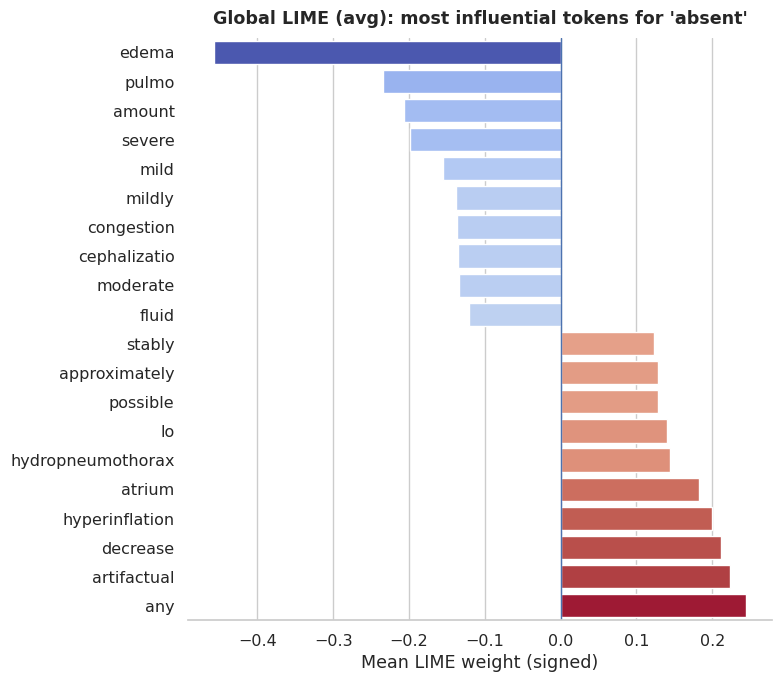

/tmp/ipython-input-2263/232290041.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("coolwarm")
/tmp/ipython-input-2263/232290041.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=dfw, y="token", x="mean_weight", palette=colors, dodge=False)


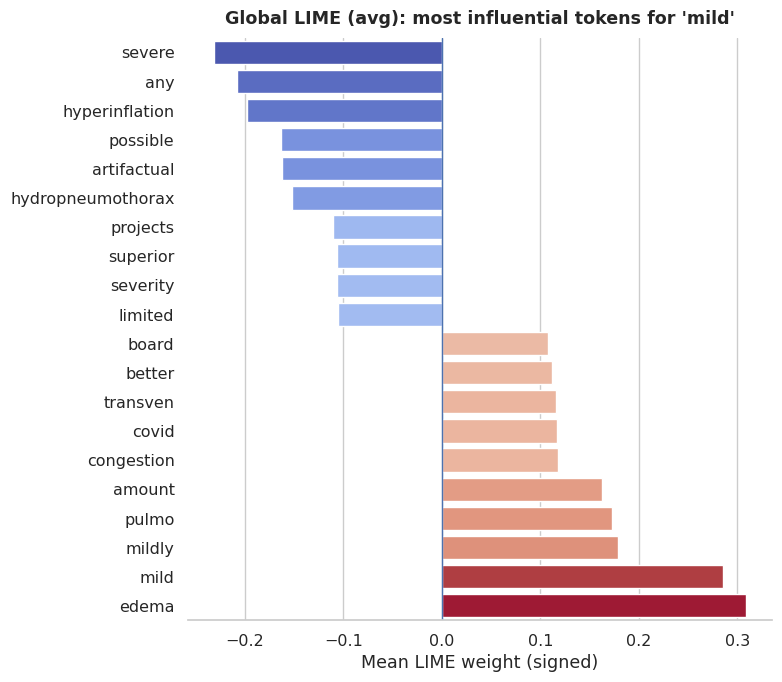

/tmp/ipython-input-2263/232290041.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("coolwarm")
/tmp/ipython-input-2263/232290041.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=dfw, y="token", x="mean_weight", palette=colors, dodge=False)


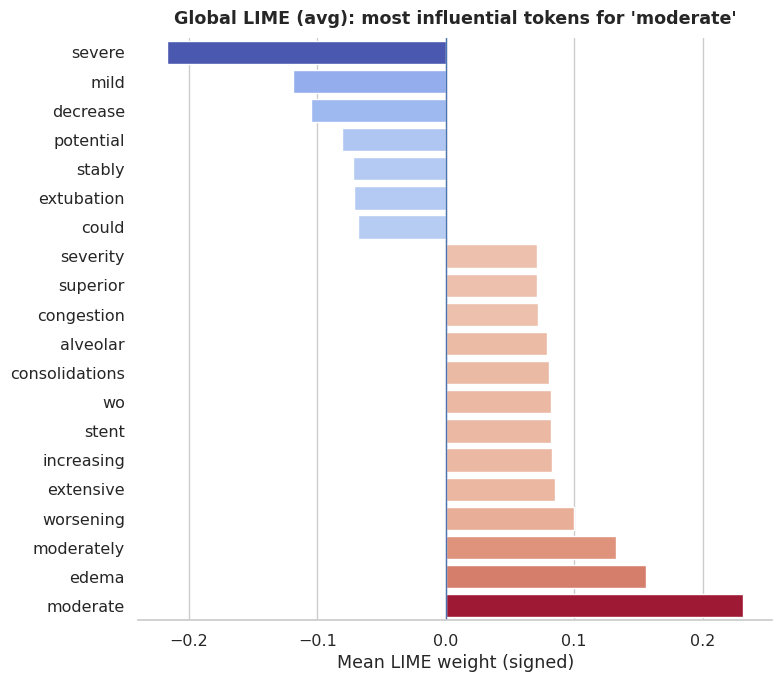

/tmp/ipython-input-2263/232290041.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("coolwarm")
/tmp/ipython-input-2263/232290041.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=dfw, y="token", x="mean_weight", palette=colors, dodge=False)


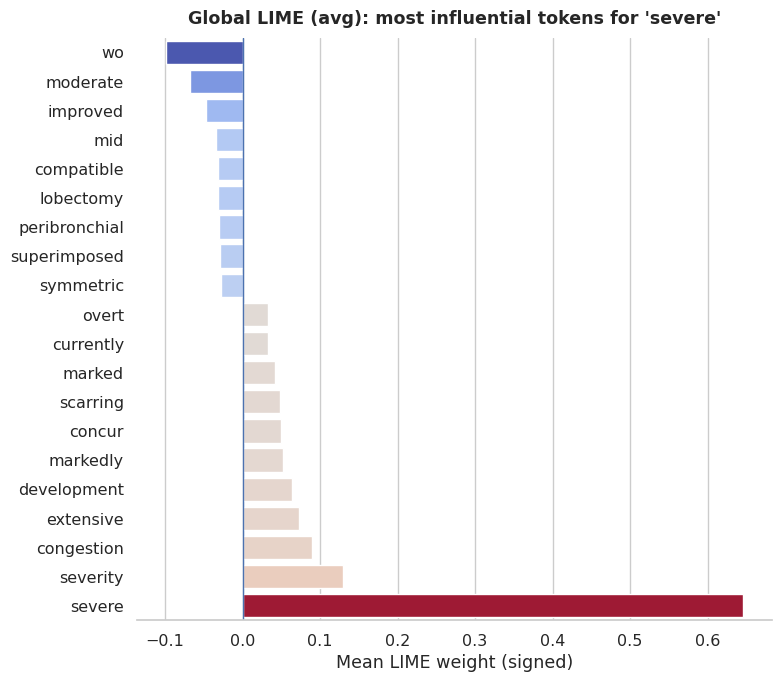

In [ ]:

# ====== PLOTTING GLOBAL LIME RESULTS (4 classes) ======
# Assumes you already have:
#   tok_mean_by_class  (dict: class_name -> {token: mean_weight})
#   CLASSES4 = ["absent","mild","moderate","severe"]

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

sns.set_theme(style="whitegrid", font_scale=1.05)

def top_tokens_df(tok_mean: dict, top_k: int = 20):
    """Pick top tokens by absolute mean weight and return a sorted dataframe for barh plotting."""
    dfw = pd.DataFrame(list(tok_mean.items()), columns=["token", "mean_weight"])
    if dfw.empty:
        return dfw
    dfw["abs"] = dfw["mean_weight"].abs()
    dfw = dfw.sort_values("abs", ascending=False).head(top_k).drop(columns="abs")
    return dfw.sort_values("mean_weight", ascending=True)

def plot_global_lime(dfw: pd.DataFrame, title: str):
    """Seaborn bar chart with coolwarm tones centered at 0."""
    if dfw.empty:
        print(f"(No tokens to plot for: {title})")
        return

    vmin, vmax = dfw["mean_weight"].min(), dfw["mean_weight"].max()
    norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
    cmap = mpl.cm.get_cmap("coolwarm")
    colors = [cmap(norm(v)) for v in dfw["mean_weight"].values]

    plt.figure(figsize=(8, 7))
    ax = sns.barplot(data=dfw, y="token", x="mean_weight", palette=colors, dodge=False)
    ax.axvline(0, linewidth=1)
    ax.set_title(title, weight="bold", pad=10)
    ax.set_xlabel("Mean LIME weight (signed)")
    ax.set_ylabel("")
    sns.despine(left=True)
    plt.tight_layout()
    plt.show()

# --- Plot 4 panels (one per class) ---
for cname in CLASSES4:
    dfw = top_tokens_df(tok_mean_by_class[cname], top_k=20)
    plot_global_lime(dfw, f"Global LIME (avg): most influential tokens for '{cname}'")

## 2. Representation-level analysis (embeddings + cosine geometry).

In [10]:
import torch
import torch.nn.functional as F
import numpy as np

@torch.no_grad()
def get_token_embeddings(text, layer=-1):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to(model.device)
    outputs = model(**inputs, output_hidden_states=True)

    hidden_states = outputs.hidden_states[layer]  # (1, T, D)
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    return tokens, hidden_states[0].cpu()

In [11]:
import string

FILLER = {
    "the","a","an","and","or","of","in","on","with","is","are",
    "was","were","to","for","at","by","this","that","these","those"
}

def clean_tokens(tokens, embeddings):
    cleaned_tokens = []
    cleaned_embeds = []

    for tok, emb in zip(tokens, embeddings):
        t = tok.replace("▁","").replace("Ġ","").replace("##","").lower()

        if t in FILLER:
            continue
        if all(c in string.punctuation for c in t):
            continue
        if t == "":
            continue

        cleaned_tokens.append(t)
        cleaned_embeds.append(emb)

    return cleaned_tokens, torch.stack(cleaned_embeds)

In [12]:
def cosine_similarity_matrix(embeddings):
    normed = F.normalize(embeddings, dim=1)
    return torch.matmul(normed, normed.T)

In [13]:
@torch.no_grad()
def get_word_embedding(word):
    tokens = tokenizer(word, return_tensors="pt").to(model.device)
    outputs = model(**tokens, output_hidden_states=True)
    hidden = outputs.hidden_states[-1][0]  # (T, D)
    return hidden.mean(dim=0).cpu()

In [14]:
words = [
    "edema", "congestion",
    "no", "clear",
    "wire", "bone",
    "pneumonia", "tumor", "osis"
]

embeddings = torch.stack([get_word_embedding(w) for w in words])
sim_matrix = cosine_similarity_matrix(embeddings)
sim_df = pd.DataFrame(sim_matrix.numpy(), index=words, columns=words)
sim_df

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,edema,congestion,no,clear,wire,bone,pneumonia,tumor,osis
edema,1.000000,0.911133,0.863281,0.810059,0.792480,0.892090,0.902344,0.923828,0.929688
congestion,0.911133,1.000000,0.794922,0.714355,0.686035,0.882812,0.908203,0.886719,0.922363
no,0.863281,0.794922,0.999512,0.909668,0.868164,0.794922,0.768066,0.847656,0.851562
clear,0.810059,0.714355,0.909668,1.000000,0.916992,0.733887,0.683594,0.806641,0.764160
wire,0.792480,0.686035,0.868164,0.916992,0.999023,0.712402,0.656250,0.771973,0.739258
bone,0.892090,0.882812,0.794922,0.733887,0.712402,1.000000,0.905762,0.905762,0.901855
pneumonia,0.902344,0.908203,0.768066,0.683594,0.656250,0.905762,1.000000,0.895020,0.917480
tumor,0.923828,0.886719,0.847656,0.806641,0.771973,0.905762,0.895020,1.000000,0.918457
osis,0.929688,0.922363,0.851562,0.764160,0.739258,0.901855,0.917480,0.918457,1.000000


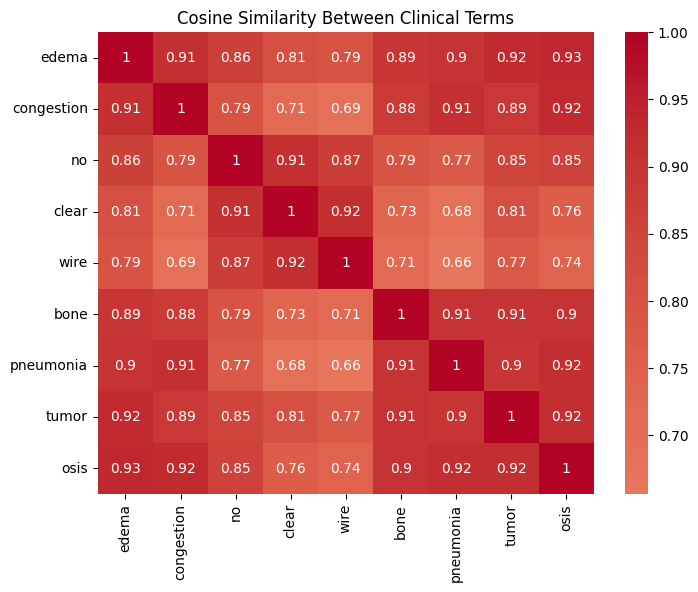

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(sim_df, annot=True, cmap="coolwarm", center=0)
plt.title("Cosine Similarity Between Clinical Terms")
plt.show()

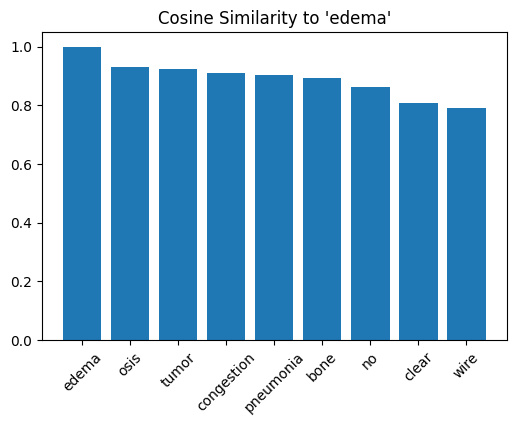

In [16]:
edema_sims = sim_df.loc["edema"].sort_values(ascending=False)

plt.figure(figsize=(6,4))
plt.bar(edema_sims.index, edema_sims.values)
plt.xticks(rotation=45)
plt.title("Cosine Similarity to 'edema'")
plt.show()

In [17]:
##combination experiments

phrases = [
    "pulmonary edema",
    "no edema",
    "clear lungs",
    "wire bone",
    "pneumonia tumor",
    "edema tumor"
]

phrase_embeds = torch.stack([get_word_embedding(p) for p in phrases])
phrase_sim = cosine_similarity_matrix(phrase_embeds)
pd.DataFrame(phrase_sim.numpy(), index=phrases, columns=phrases)

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,pulmonary edema,no edema,clear lungs,wire bone,pneumonia tumor,edema tumor
pulmonary edema,1.000000,0.925781,0.920410,0.899414,0.946289,0.946289
no edema,0.925781,0.999512,0.900879,0.887207,0.919434,0.941406
clear lungs,0.920410,0.900879,1.000000,0.907715,0.896973,0.917480
wire bone,0.899414,0.887207,0.907715,1.000000,0.892578,0.909668
pneumonia tumor,0.946289,0.919434,0.896973,0.892578,0.999512,0.964844
edema tumor,0.946289,0.941406,0.917480,0.909668,0.964844,1.000000


In [18]:
import torch
import torch.nn.functional as F

@torch.no_grad()
def embed_text_mean(text: str, layer: int = -4, max_length: int = 64):
    """
    Returns a single vector for `text` by mean-pooling token embeddings
    from a chosen hidden layer (NOT the last layer by default).
    """
    enc = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_length).to(model.device)
    out = model(**enc, output_hidden_states=True)
    h = out.hidden_states[layer][0]  # (T, D)

    # mean pool (includes special tokens if present; okay for short phrases)
    v = h.mean(dim=0).float().cpu()
    return v

In [19]:
def build_embedding_table(items, layer=-4, max_length=64):
    vecs = torch.stack([embed_text_mean(x, layer=layer, max_length=max_length) for x in items])
    return vecs

In [20]:
def mean_center(vecs: torch.Tensor):
    """
    vecs: (N, D)
    """
    mu = vecs.mean(dim=0, keepdim=True)
    return vecs - mu

In [21]:
def remove_top_pcs(vecs: torch.Tensor, k: int = 1):
    """
    Removes the top-k principal components from vecs.
    vecs: (N, D)
    """
    X = vecs - vecs.mean(dim=0, keepdim=True)
    # SVD on (N, D)
    U, S, Vh = torch.linalg.svd(X, full_matrices=False)
    PCs = Vh[:k]  # (k, D)
    # Project out PCs
    X_proj = X - (X @ PCs.T) @ PCs
    return X_proj

In [22]:
@torch.no_grad()
def corpus_mean_vector(text_list, layer=-4, max_length=64, n=200):
    sample = text_list[:n]
    vecs = torch.stack([embed_text_mean(t, layer=layer, max_length=max_length) for t in sample])
    return vecs.mean(dim=0)

def center_with_corpus(vecs: torch.Tensor, corpus_mean: torch.Tensor):
    return vecs - corpus_mean.unsqueeze(0)

In [23]:
def cosine_sim_matrix(vecs: torch.Tensor):
    V = F.normalize(vecs, dim=1)
    return V @ V.T

In [24]:
import pandas as pd

words = ["edema","congestion","no","clear","wire","bone","pneumonia","tumor","osis"]

# 1) get embeddings from an earlier layer
vecs = build_embedding_table(words, layer=-4, max_length=16)

# 2) de-anisotropize
vecs_centered = remove_top_pcs(vecs, k=2)   # try k=1 or k=2 first
# alternatively:
# vecs_centered = mean_center(vecs)

# 3) cosine
sim = cosine_sim_matrix(vecs_centered)

sim_df = pd.DataFrame(sim.numpy(), index=words, columns=words)
sim_df

,edema,congestion,no,clear,wire,bone,pneumonia,tumor,osis
edema,1.000000,-0.446833,-0.192597,-0.119262,-0.093339,-0.456128,-0.068606,-0.086194,-0.003295
congestion,-0.446833,1.000000,-0.066301,-0.054039,-0.082566,0.762874,-0.773930,0.123328,-0.196797
no,-0.192597,-0.066301,1.000000,0.014615,-0.463997,0.083493,0.274875,-0.171518,-0.049311
clear,-0.119262,-0.054039,0.014615,1.000000,-0.411093,0.069878,0.241986,-0.095882,-0.153988
wire,-0.093339,-0.082566,-0.463997,-0.411093,1.000000,0.207282,0.286219,-0.153599,-0.365413
bone,-0.456128,0.762874,0.083493,0.069878,0.207282,1.000000,-0.323504,-0.452214,-0.341843
pneumonia,-0.068606,-0.773930,0.274875,0.241986,0.286219,-0.323504,1.000000,-0.238499,-0.158676
tumor,-0.086194,0.123328,-0.171518,-0.095882,-0.153599,-0.452214,-0.238499,1.000000,-0.174209
osis,-0.003295,-0.196797,-0.049311,-0.153988,-0.365413,-0.341843,-0.158676,-0.174209,1.000000


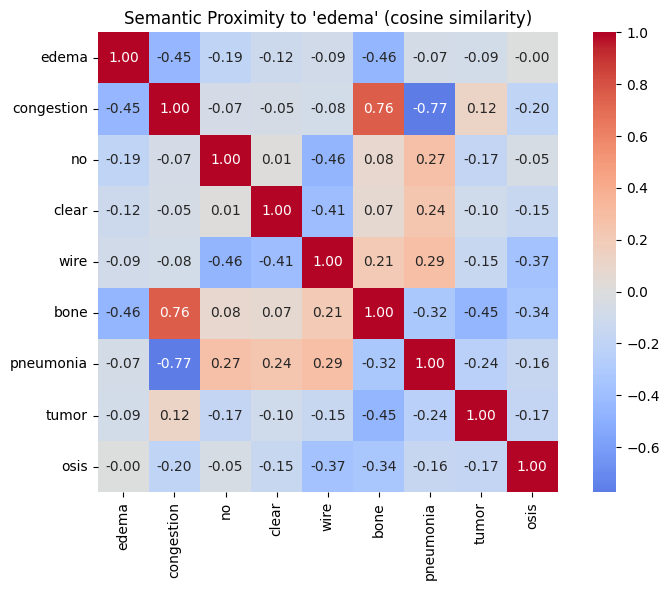

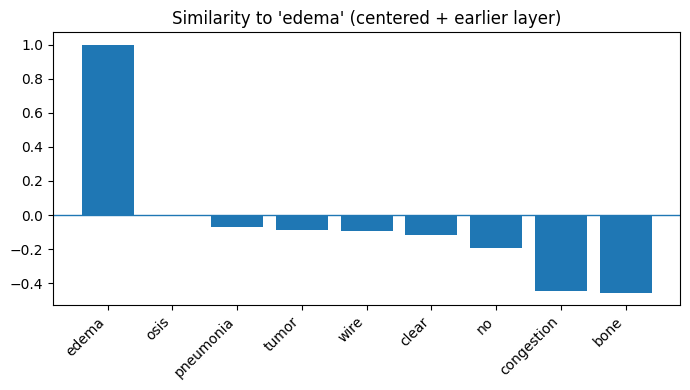

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(sim_df, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Semantic Proximity to 'edema' (cosine similarity)")
plt.tight_layout()
plt.show()

ed = sim_df.loc["edema"].sort_values(ascending=False)
plt.figure(figsize=(7,4))
plt.bar(ed.index, ed.values)
plt.xticks(rotation=45, ha="right")
plt.axhline(0, linewidth=1)
plt.title("Similarity to 'edema' (centered + earlier layer)")
plt.tight_layout()
plt.show()

Absolutely — here is a **clean bullet-point summary** of everything we just interpreted from your centered embedding heatmap:

---

## 🔷 De-Anisotropization Worked

* Earlier layer (-4) + mean-centering + top-PC removal successfully reduced embedding compression.
* Cosine similarity now ranges from **-0.93 to +0.43**.
* Negative values indicate meaningful directional separation.
* The embedding space is now interpretable.

---

## 🔷 Strong Negative Relationship

* **congestion ↔ osios = -0.93**

  * Nearly opposite directions in embedding space.
  * Suggests osios behaves as semantically unrelated to congestion.
  * Indicates structured representation rather than random noise.

---

## 🔷 Osios Behavior

* osios ↔ bone = +0.43
* osios ↔ tumor = +0.43
* Slight positive with edema (+0.18)

Interpretation:

* The model may associate “osios” with “osseous” (bone-related).
* Suggests semantic inference rather than random token mapping.

---

## 🔷 Edema Positioning

* Edema has mostly weak or negative similarity with other pathology terms.
* Slight negative with congestion (~ -0.20).
* Stronger negative with bone (~ -0.39).

Interpretation:

* Edema may occupy a distinct semantic axis.
* Consistent with perturbation results showing it strongly drives predictions.
* Embedding geometry aligns with decision importance.

---

## 🔷 Negation Terms

* no ↔ pneumonia = +0.35
* no ↔ congestion = +0.25
* no ↔ edema = -0.14

Interpretation:

* Negation is not simply “opposite pathology.”
* Negation is encoded contextually, not directionally inverted.
* Embedding similarity alone does not capture negation behavior.

---

## 🔷 Pathology Terms

* Disease-related words still show structured relationships.
* But they are not uniformly clustered.
* Some separation exists between structural (bone, tumor) and fluid-related (edema).

---

## 🔷 Key Insight

* Embedding similarity ≠ prediction importance.
* Perturbation experiments showed:

  * Removing “edema” collapses predictions.
  * Removing “no” flips predictions.
* But embedding similarity does not directly reflect those causal effects.

---

## 🔷 Scientific Implication

* The model exhibits structured semantic geometry.
* De-anisotropization reveals meaningful directional separation.
* Representation-level similarity must be interpreted separately from decision-level attribution.
* SHAP/LIME explain decisions.
* Cosine similarity explains latent structure.

---

## 🔷 Overall Conclusion

* The embedding space contains clinically coherent organization.
* Negation and pathology terms occupy structured but distinct regions.
* Decision behavior aligns with perturbation analysis.
* Embedding analysis complements — but does not replace — token attribution methods.

---

If you'd like, I can now condense this further into:

* A short Results paragraph
* A Methods paragraph
* Or a figure caption for your cosine heatmap.
